# Study of origins of replication

### Datasets:
- Belsky set of origins with annotations for early/late replication timing, origin efficiency, footprint evidence, and nucleosome signals.
- Estimated replication timing.
- Deconvolved chromatin occupancy data.

### Ideas:
- Show the origin timing is linked to estimated replication timing.
- Show that we can analyze footprint, and nucleosome movement timing globally.
- Show a global timecourse representation.
- Show early and late examples.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.fig_origins import FigureOrigins
fig_origins = FigureOrigins('output/draft4_run/')
fig_origins.setup_data()

Creating directory: output/draft4_run//figure_origins...Directory exists. Skipping.
Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87


In [149]:
fig_origins.setup_processors(force_recompute=True)

Creating directory: output/draft4_run//figure_origins/fork_progression...Directory exists. Skipping.
Starting sliding window fork progression analysis of 437 origins...
Window parameters: 3000bp windows, 500bp stride, 101 windows per origin
1/437 (1 successful) 00:00:01.809
101/437 (101 successful) 00:02:40.397
201/437 (201 successful) 00:05:12.057
301/437 (301 successful) 00:07:55.187
Error loading window (1080000, 1090001) on chr15: Deconvolved data file not found: output/draft4_run//chromatin_deconvolution/deconvolution_data/chr15/chr15_1080000_1090001_F.npy
Please ensure deconvolution has been run for chr15
Error loading window (1080000, 1090001) on chr15: Deconvolved data file not found: output/draft4_run//chromatin_deconvolution/deconvolution_data/chr15/chr15_1080000_1090001_F.npy
Please ensure deconvolution has been run for chr15
401/437 (401 successful) 00:10:27.964
Completed processing 437 origins! (437 successful)
Saving fork progression matrices to disk...
Results saved to o

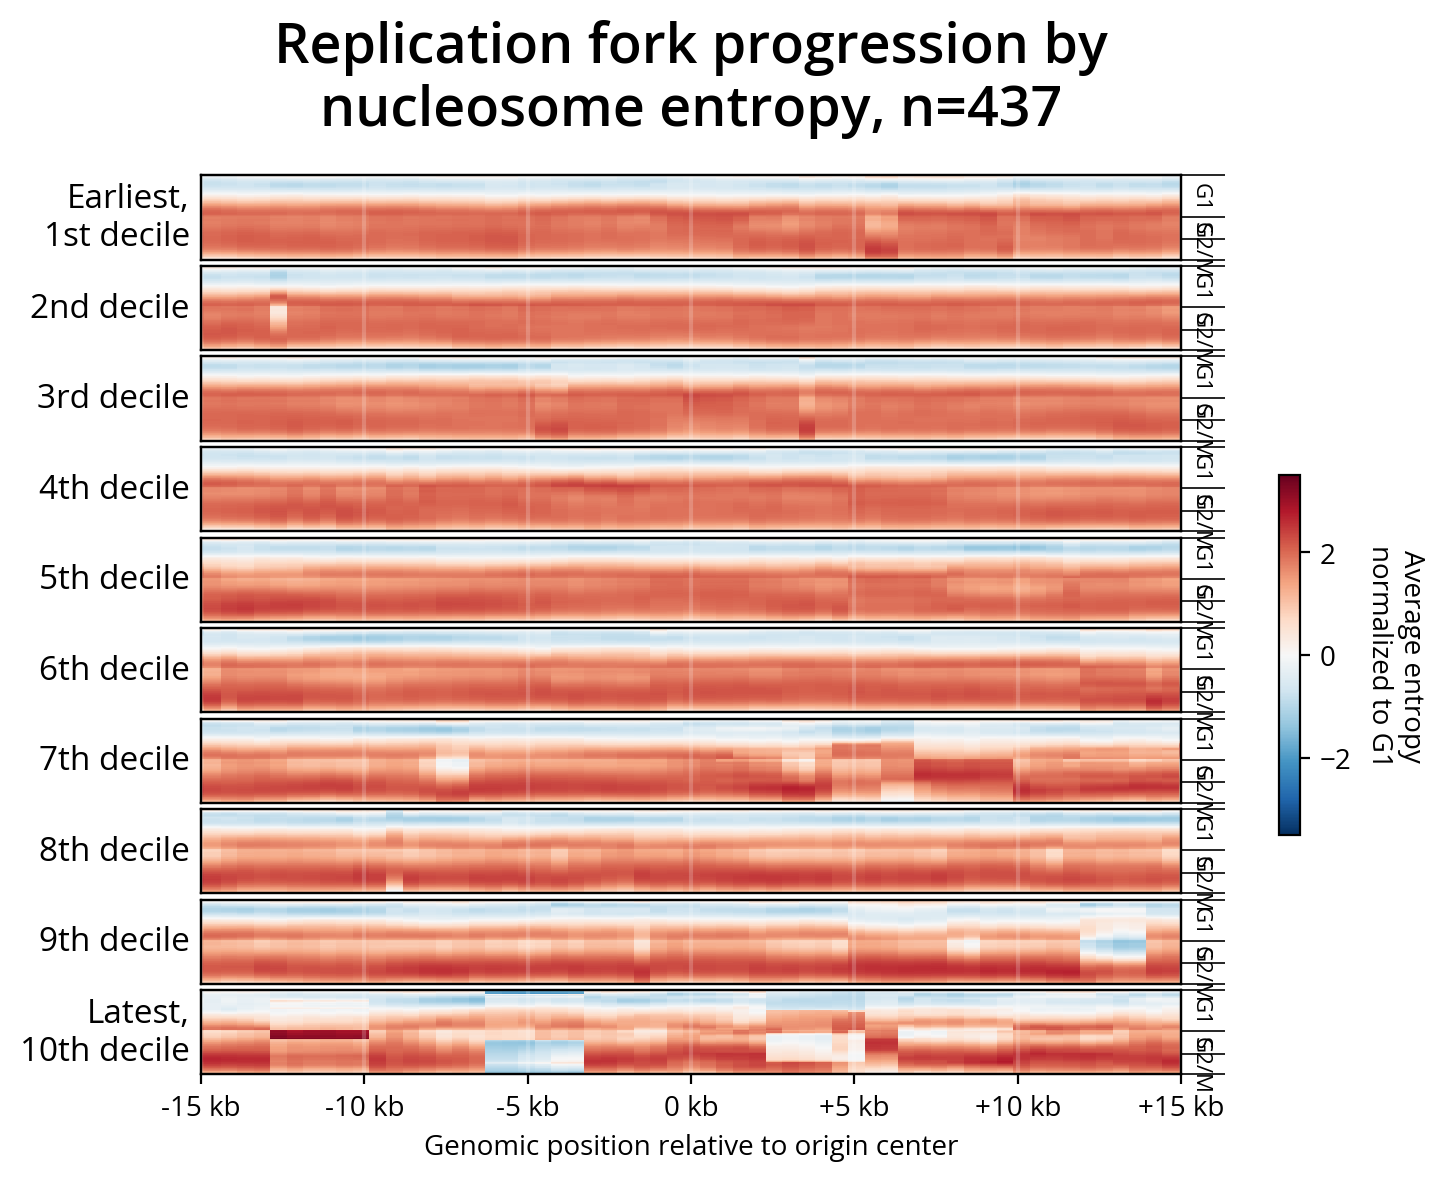

In [154]:
_ = fig_origins.fork_processor.plot_all_origin_percentiles('entropy', 
    inferred=False, num_percentiles=10)


Saved figure to: output/draft4_run//figure_origins/origin_replication_times.png
Saved figure to: output/draft4_run//figure_origins/early_origin_enrichments.png
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 12
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr12.h5, crick_rna_seq_pileup_rep1_chr12.h5
Shape: (16, 1078177) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr12.h5, crick_rna_seq_pileup_rep2_chr12.h5
Shape: (14, 1078177) (timepoints x positions)
Saved figure to: output/draft4_run//figure_origins/early_origin_locus.png
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skippi

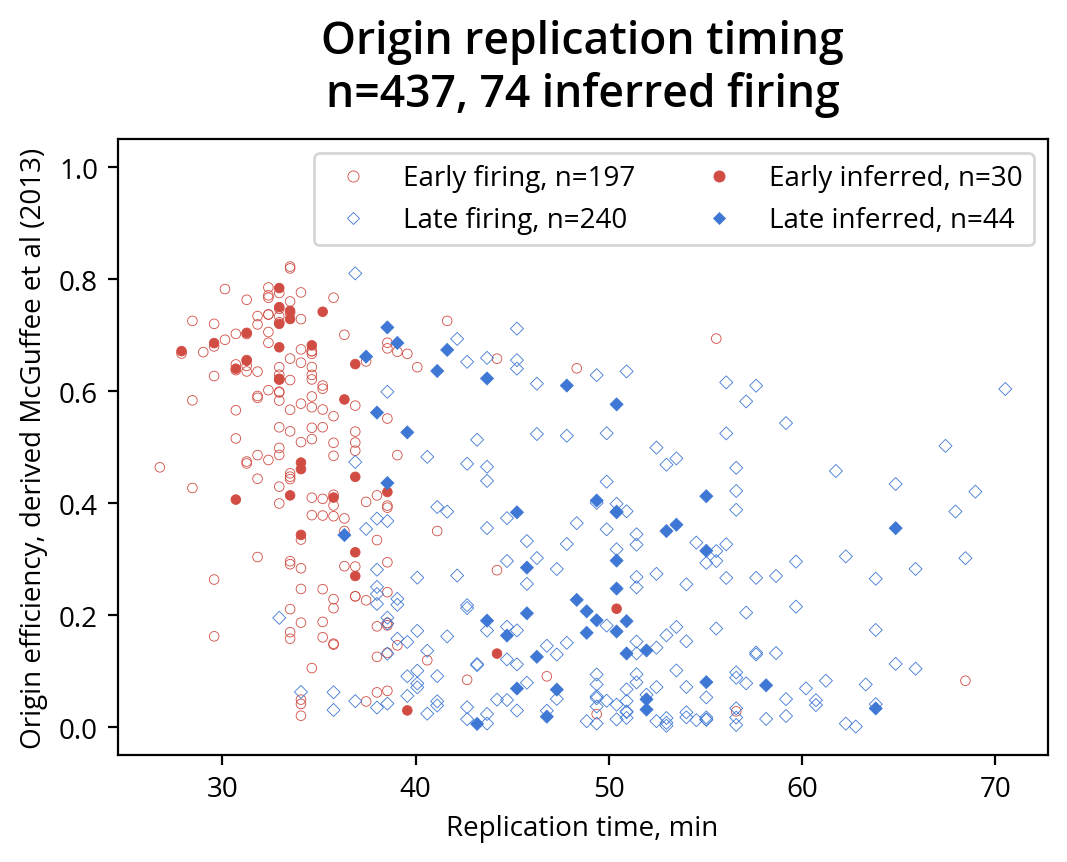

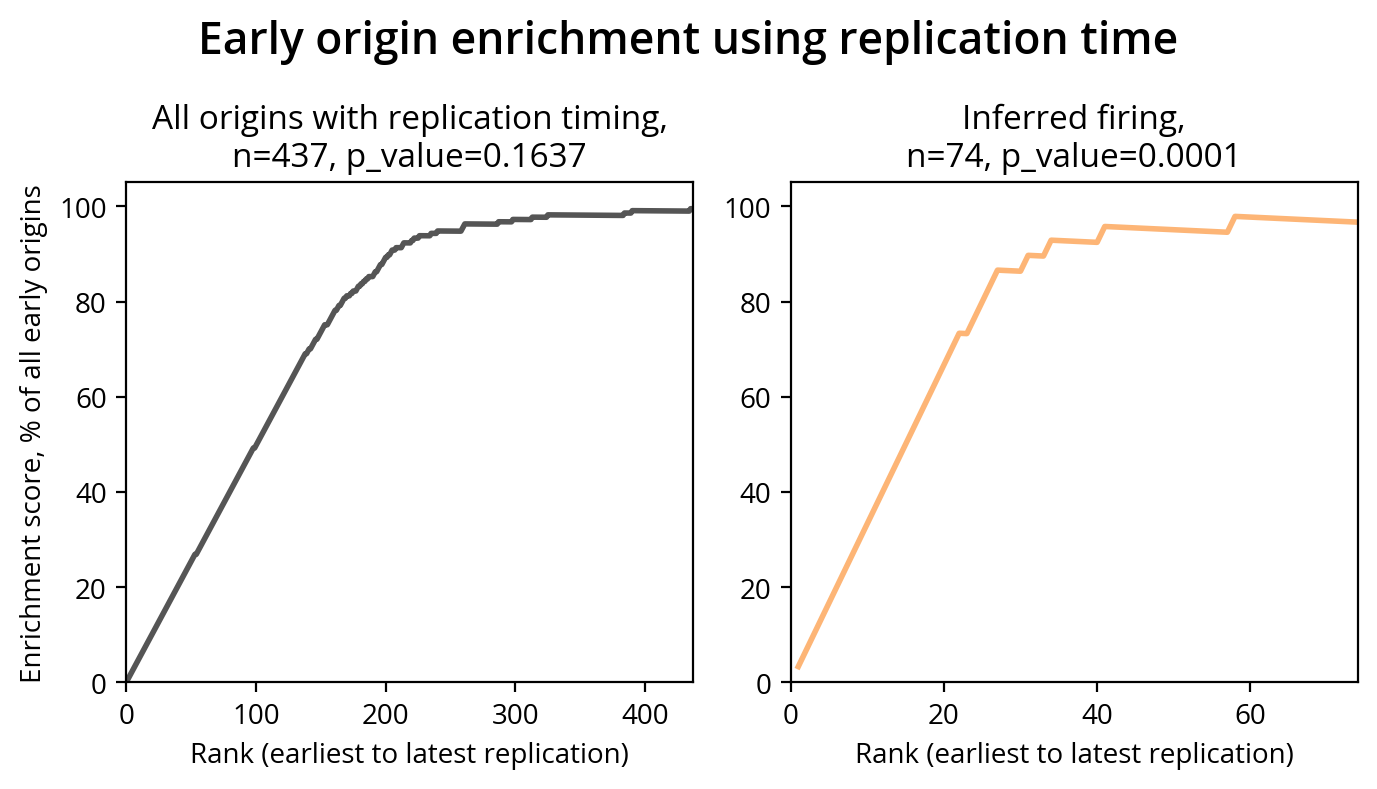

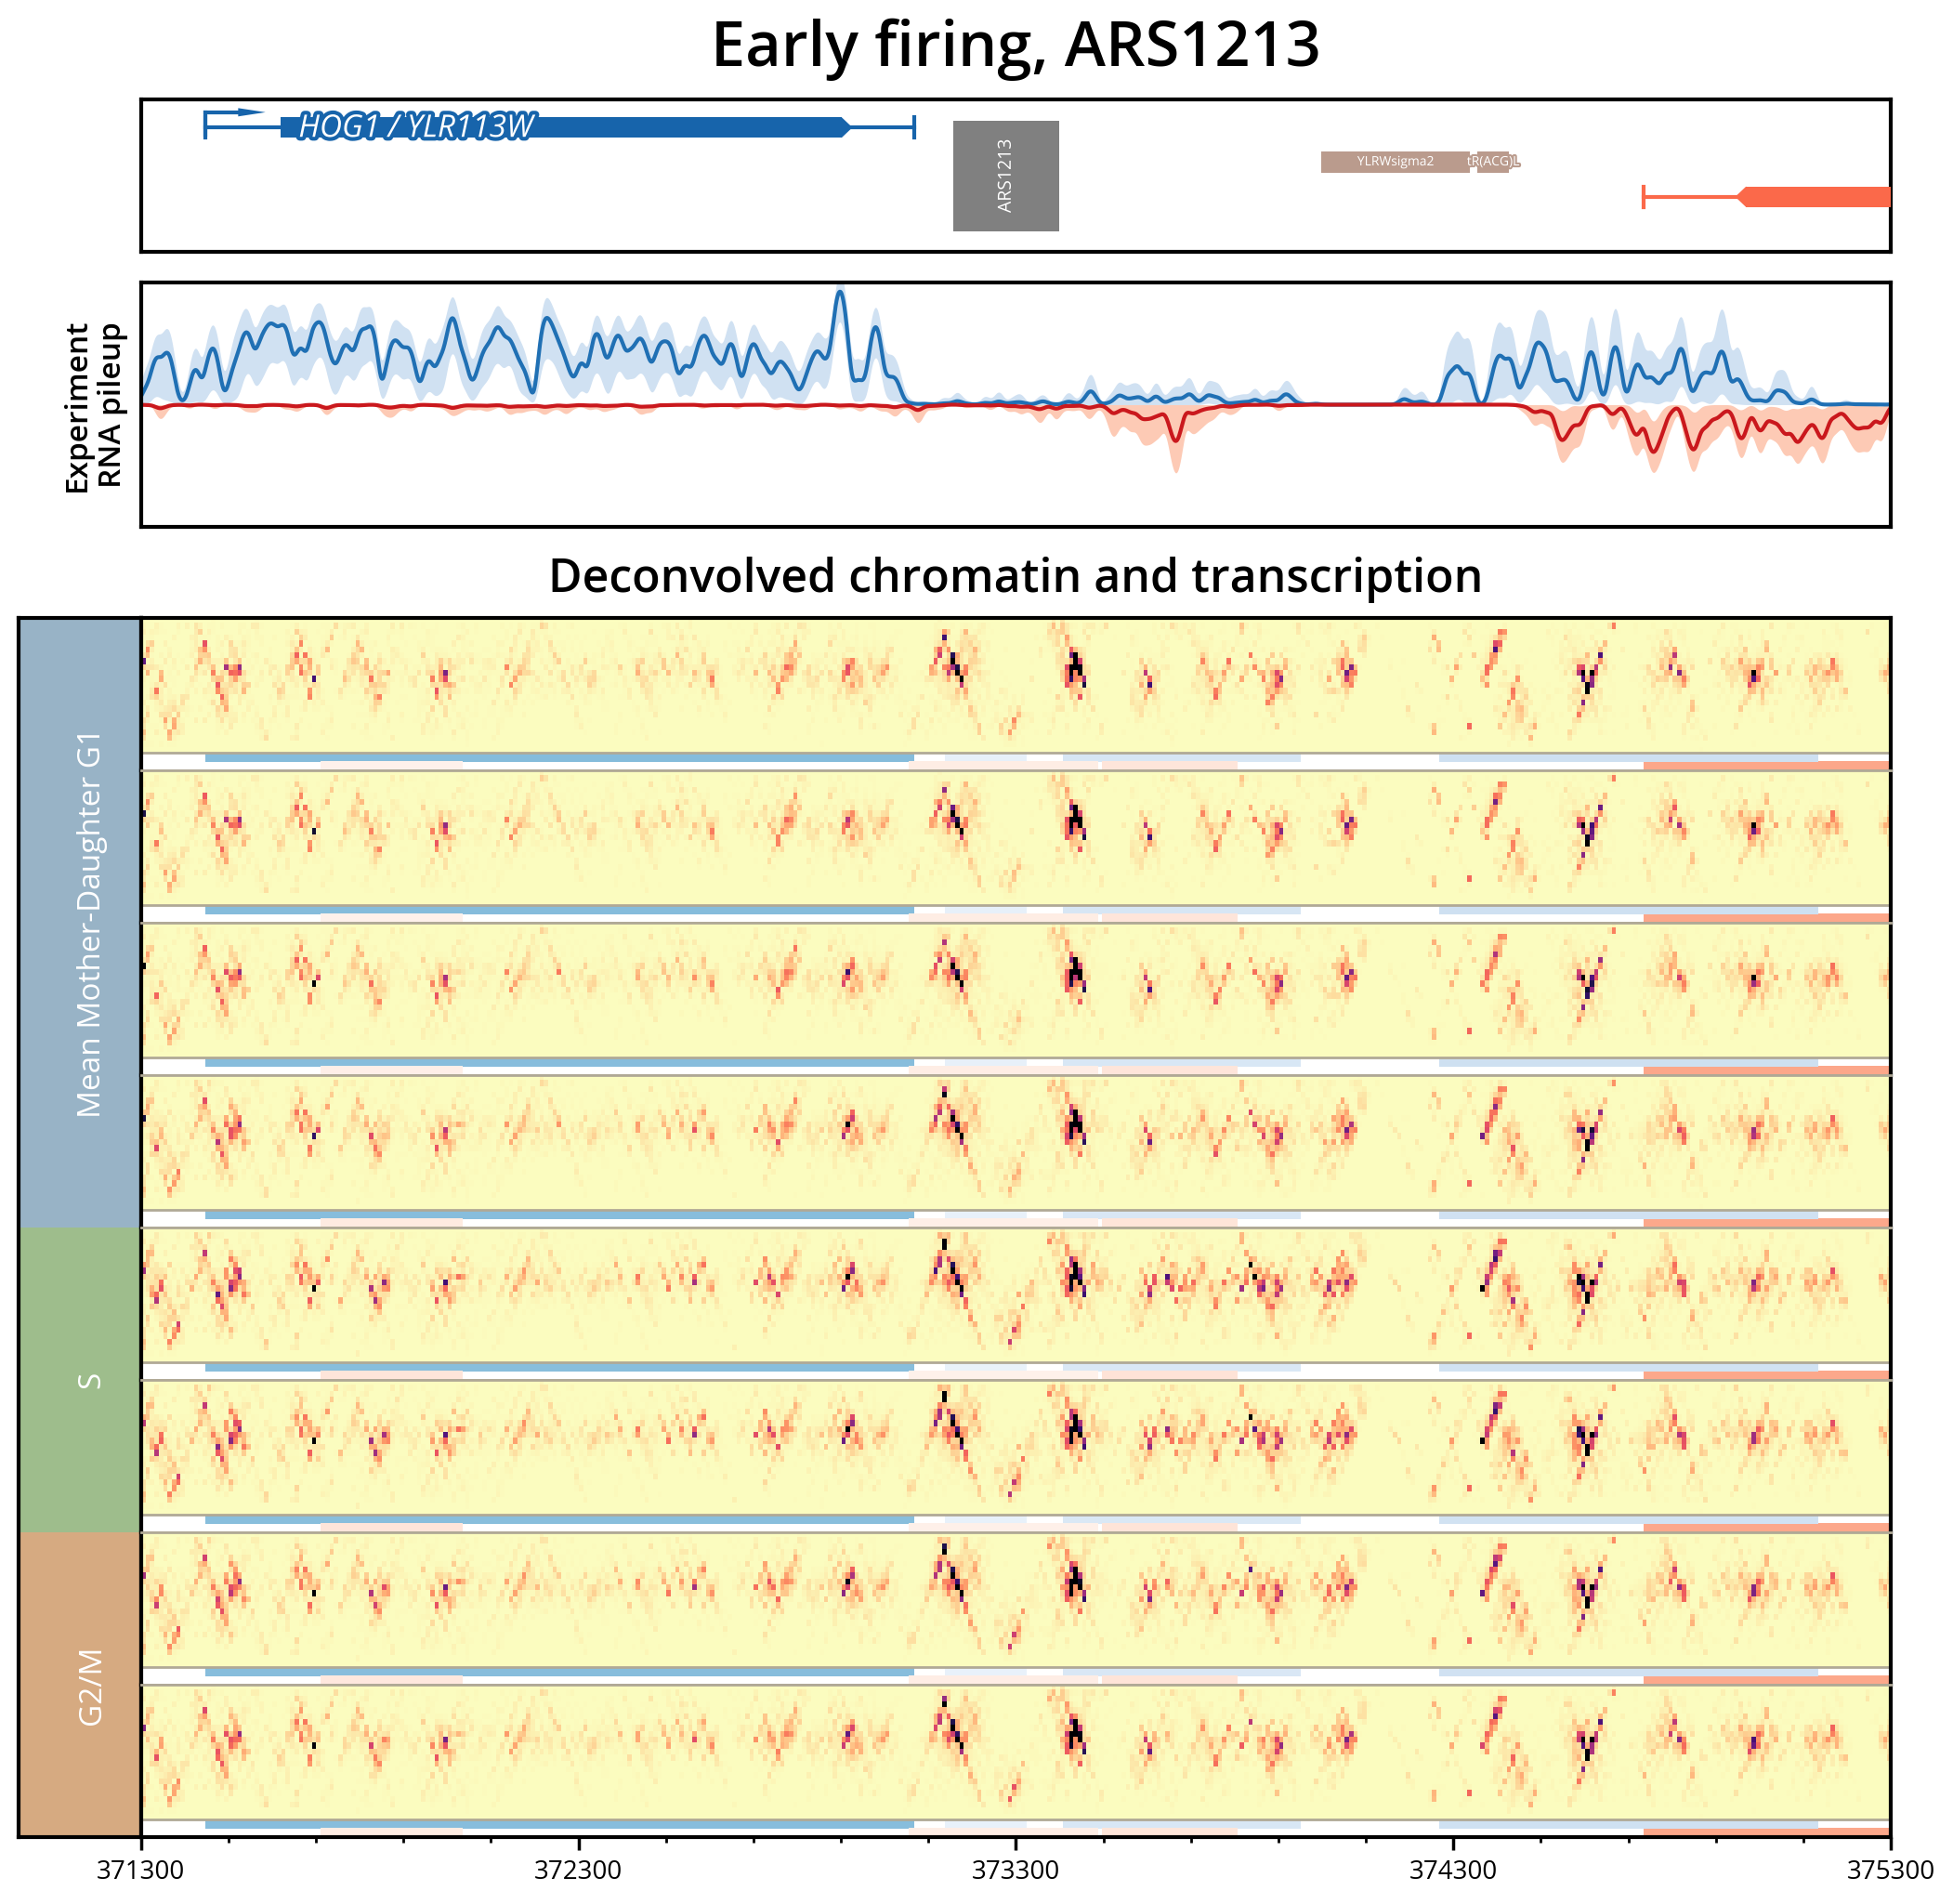

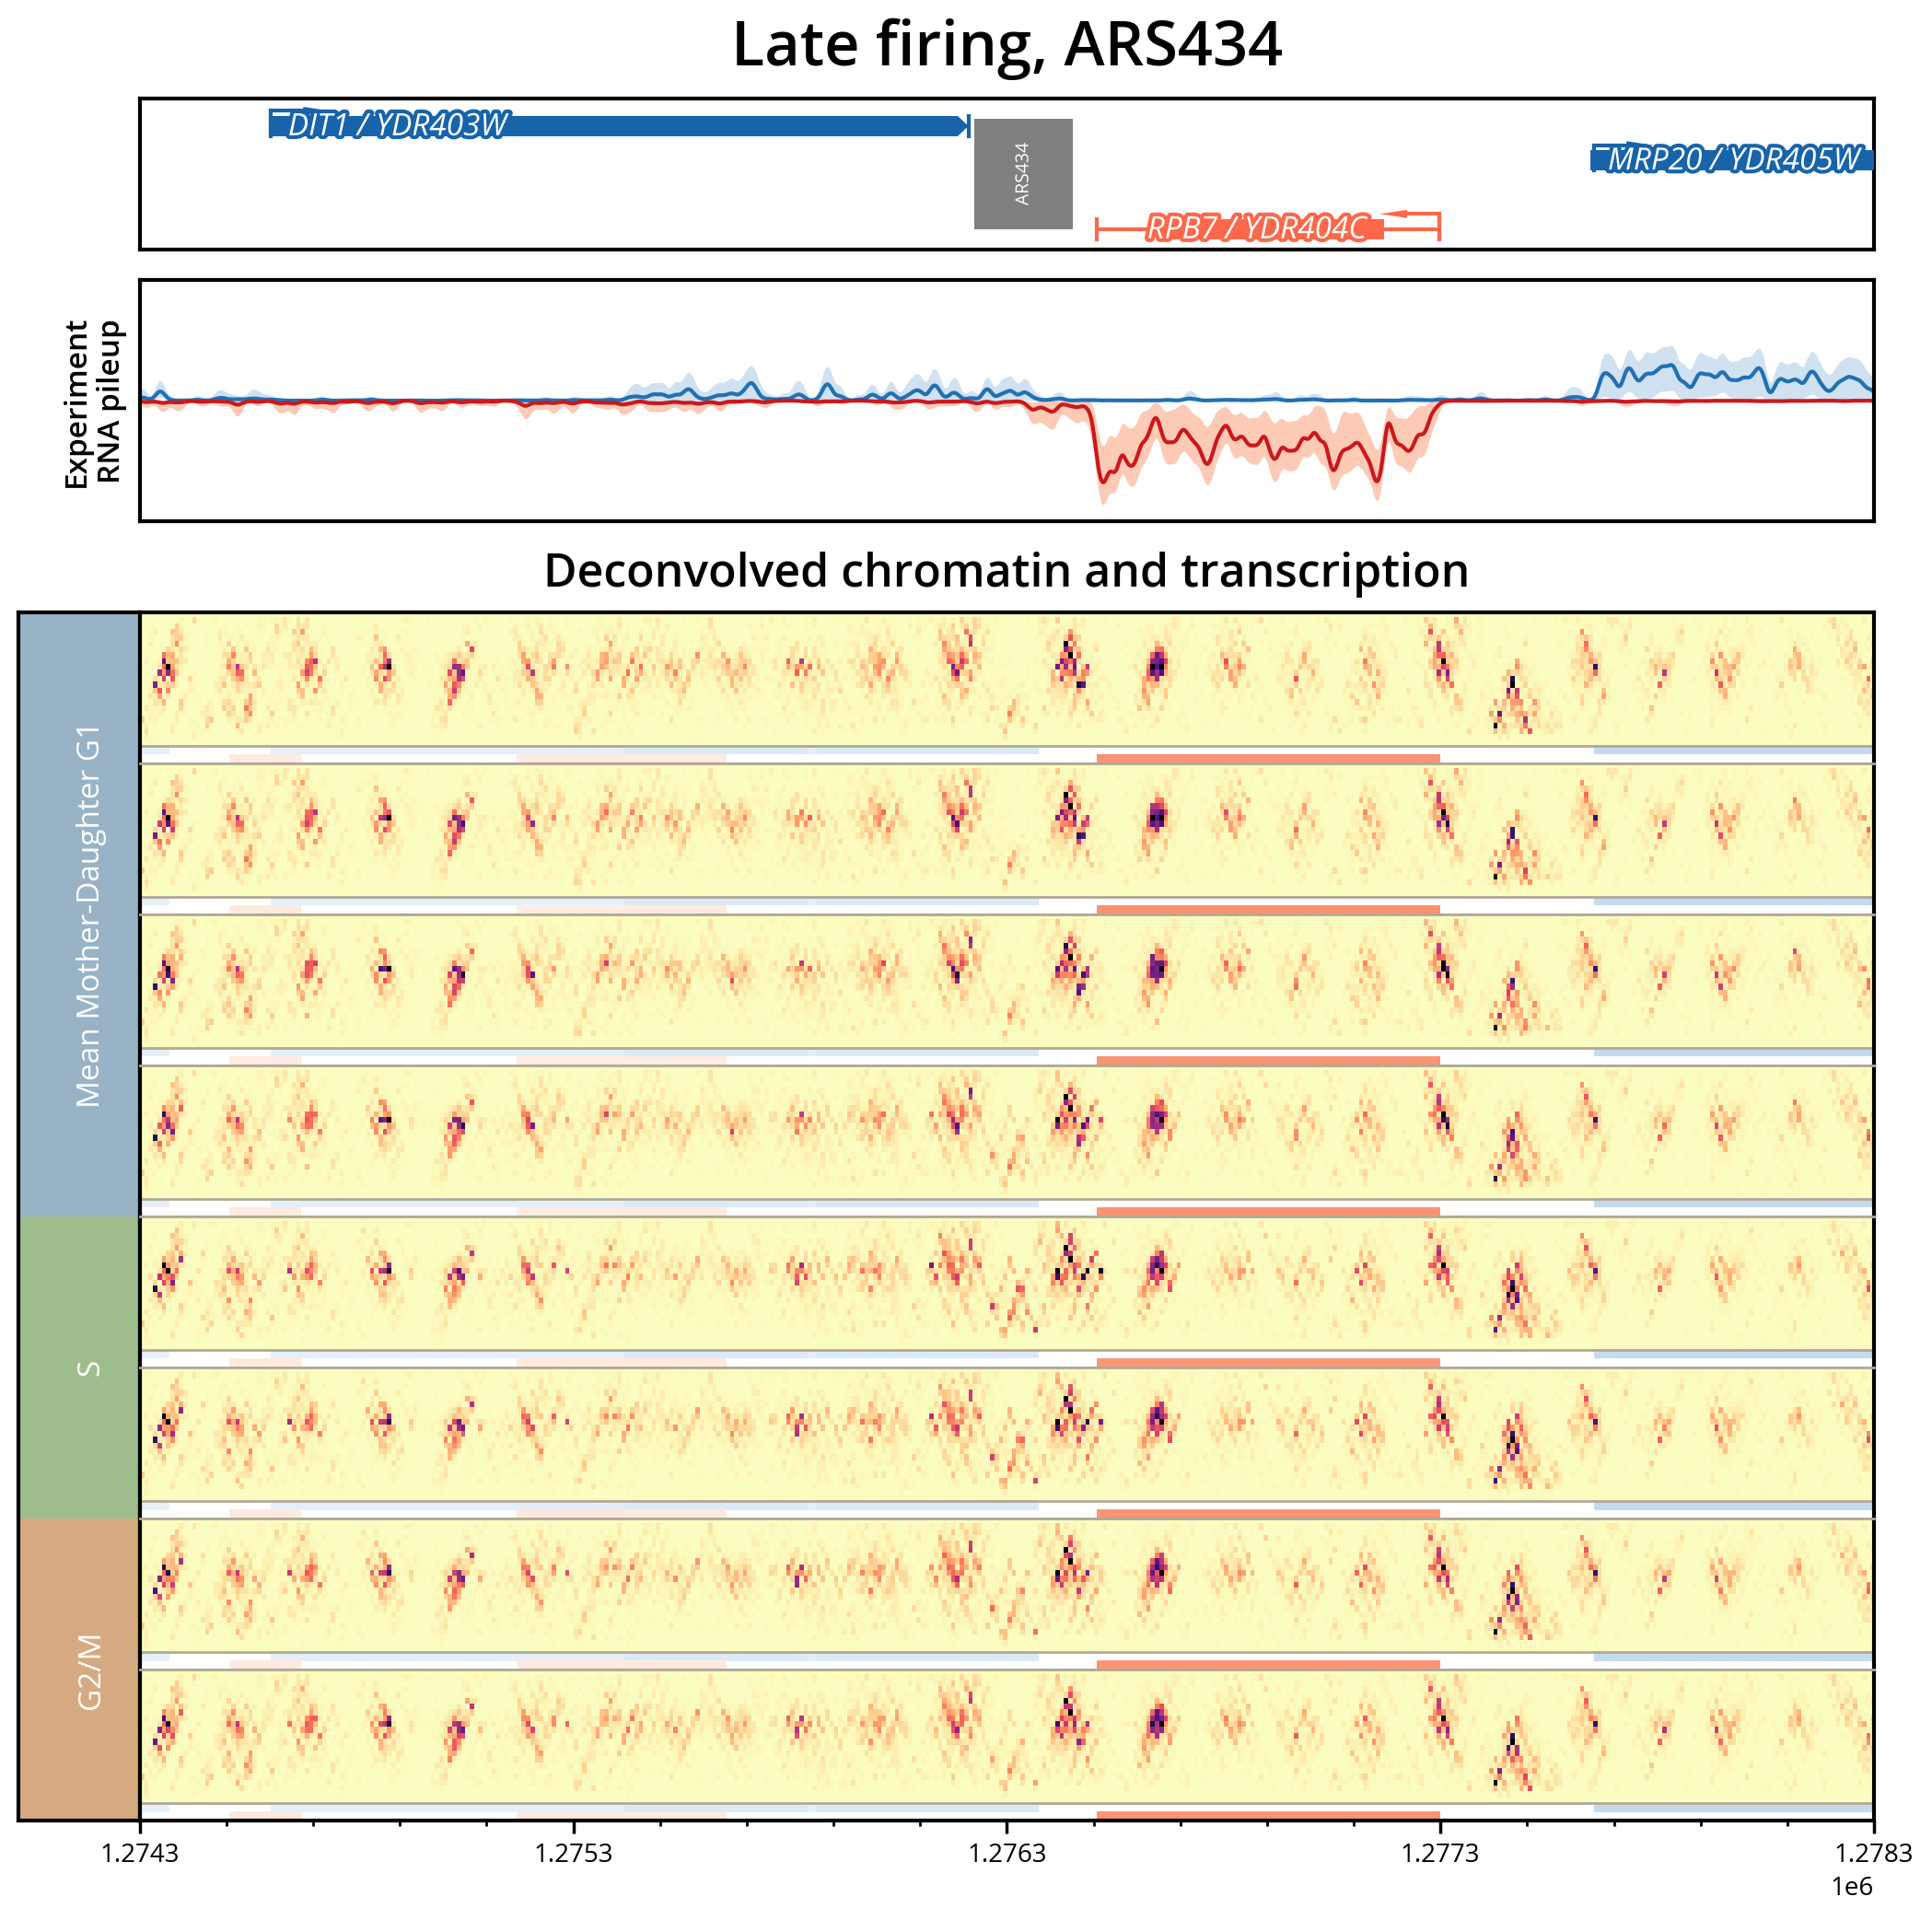

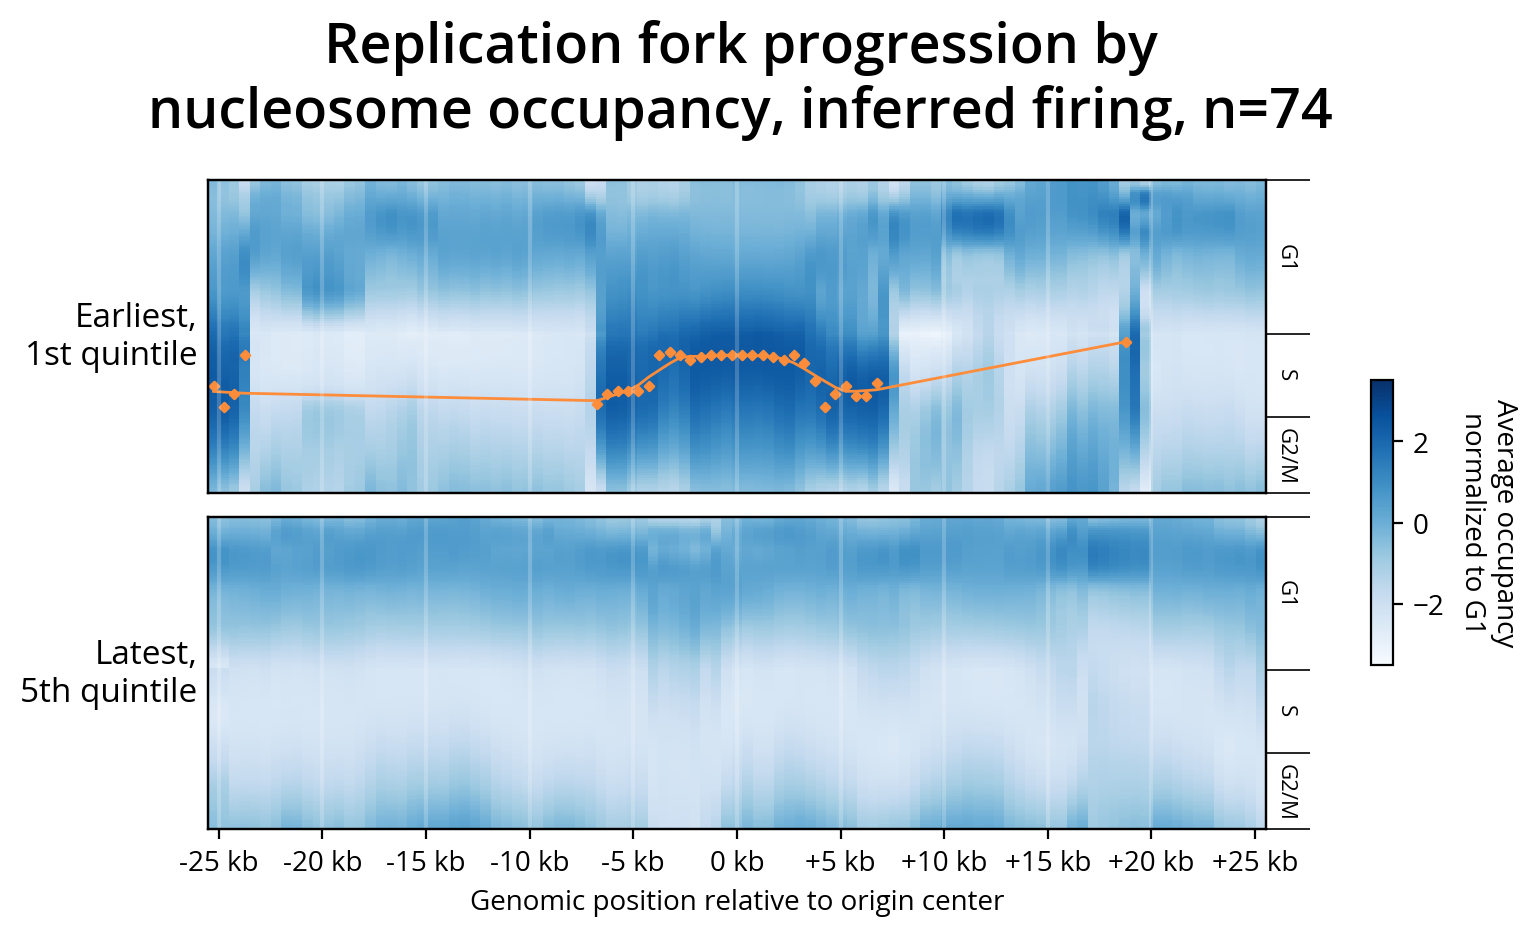

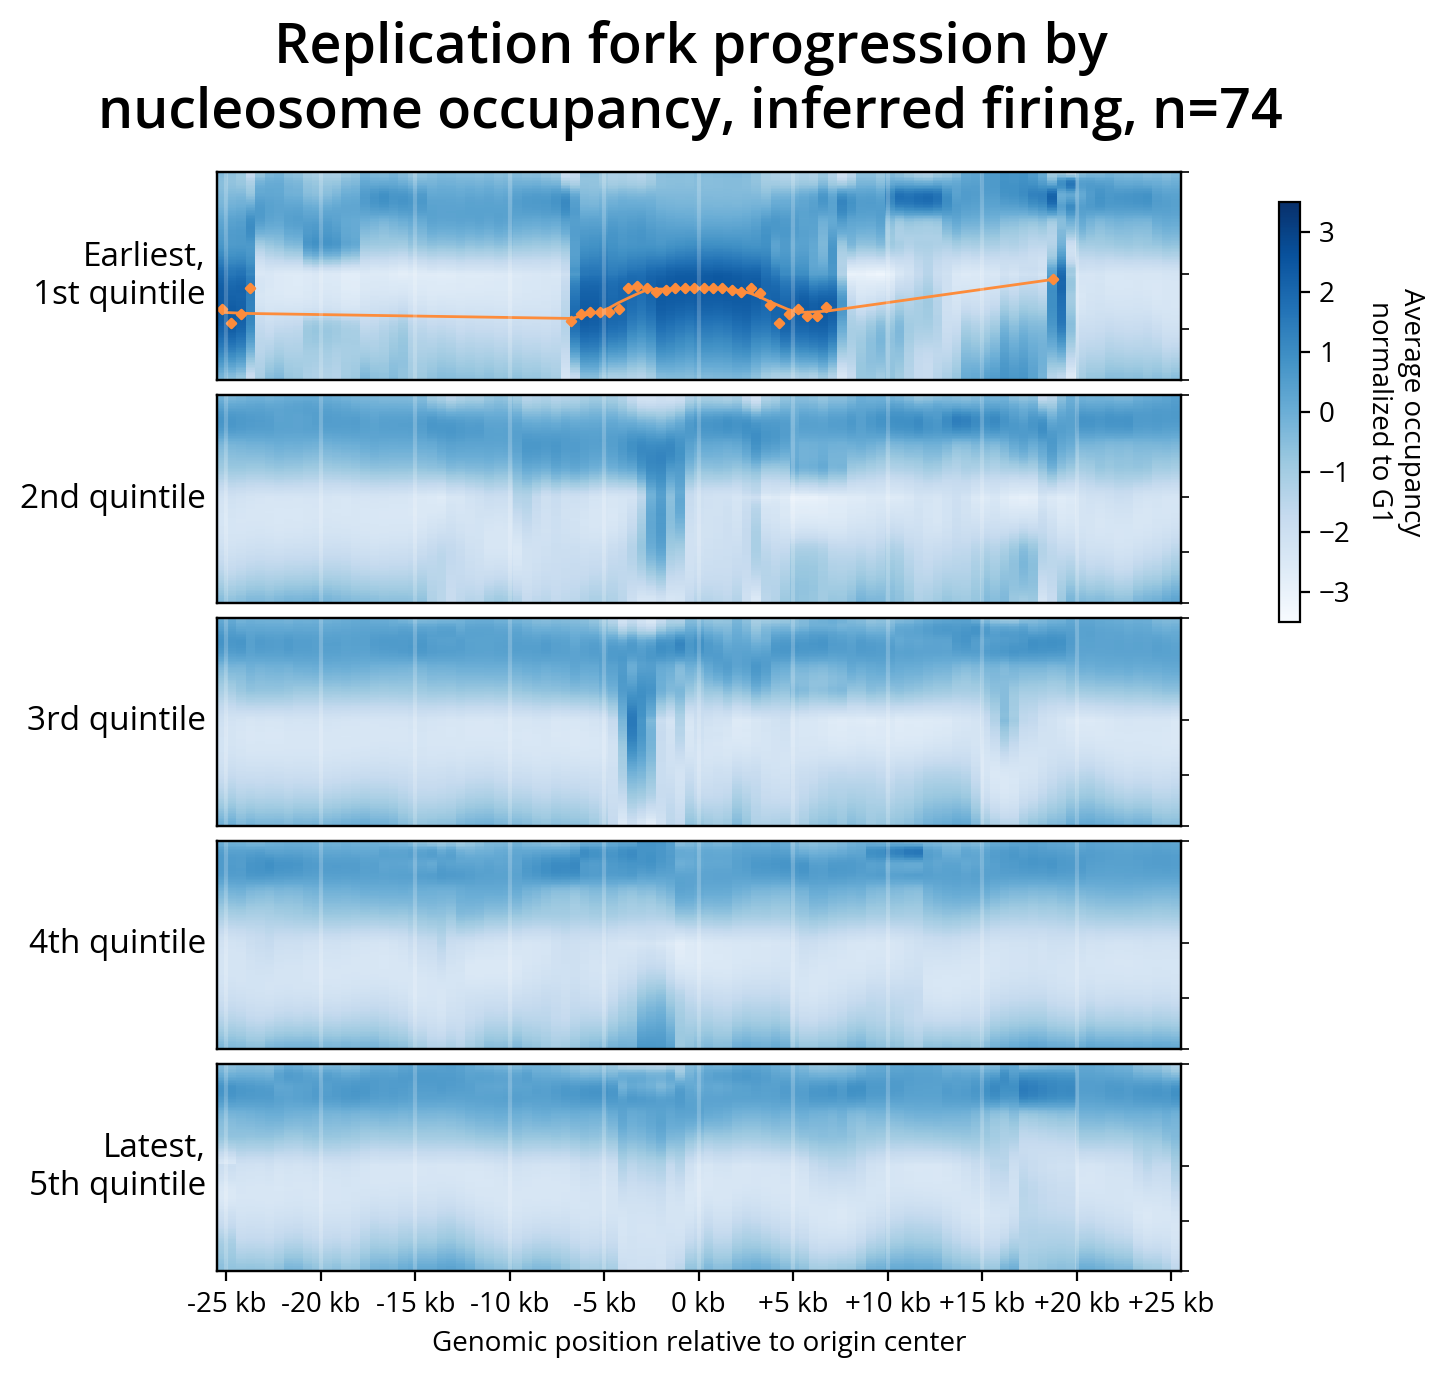

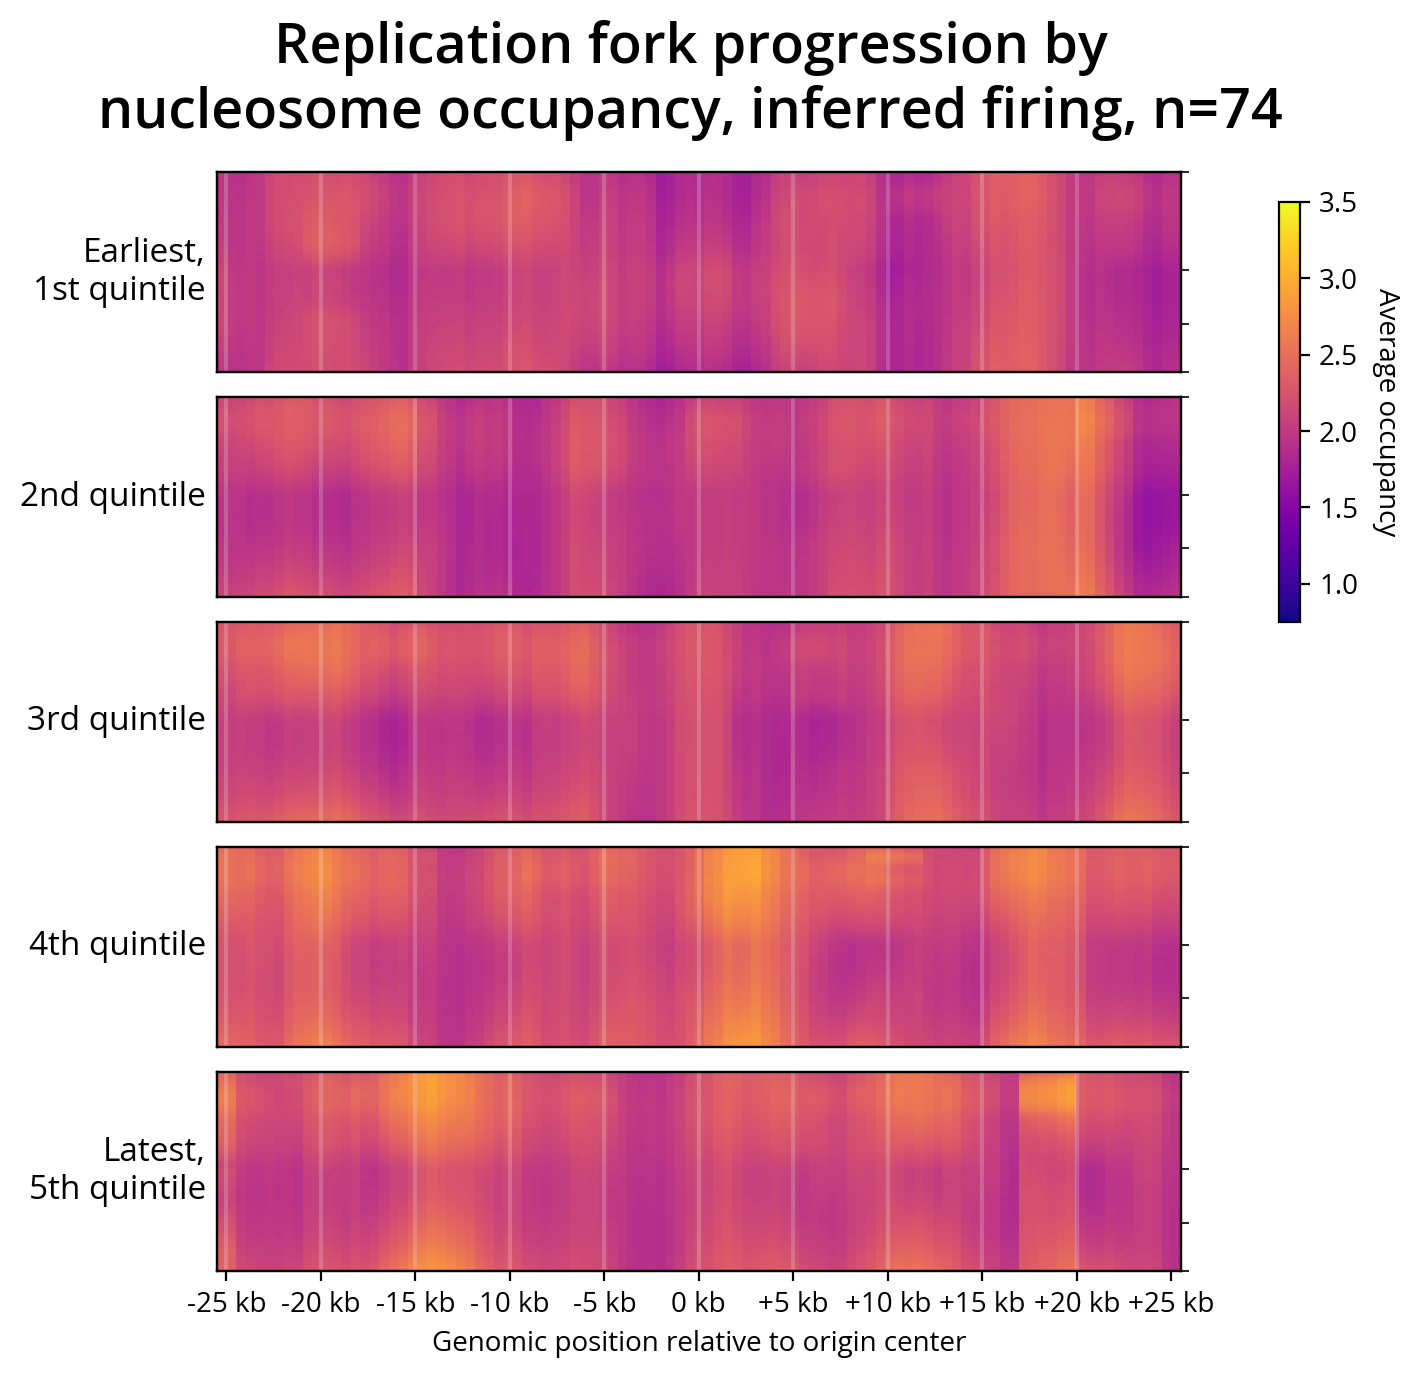

In [5]:
fig_origins.plot_all()

Debug figure saved to: output/draft4_run//Figures/Debug/Figure6_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/Figure6_Origins.png


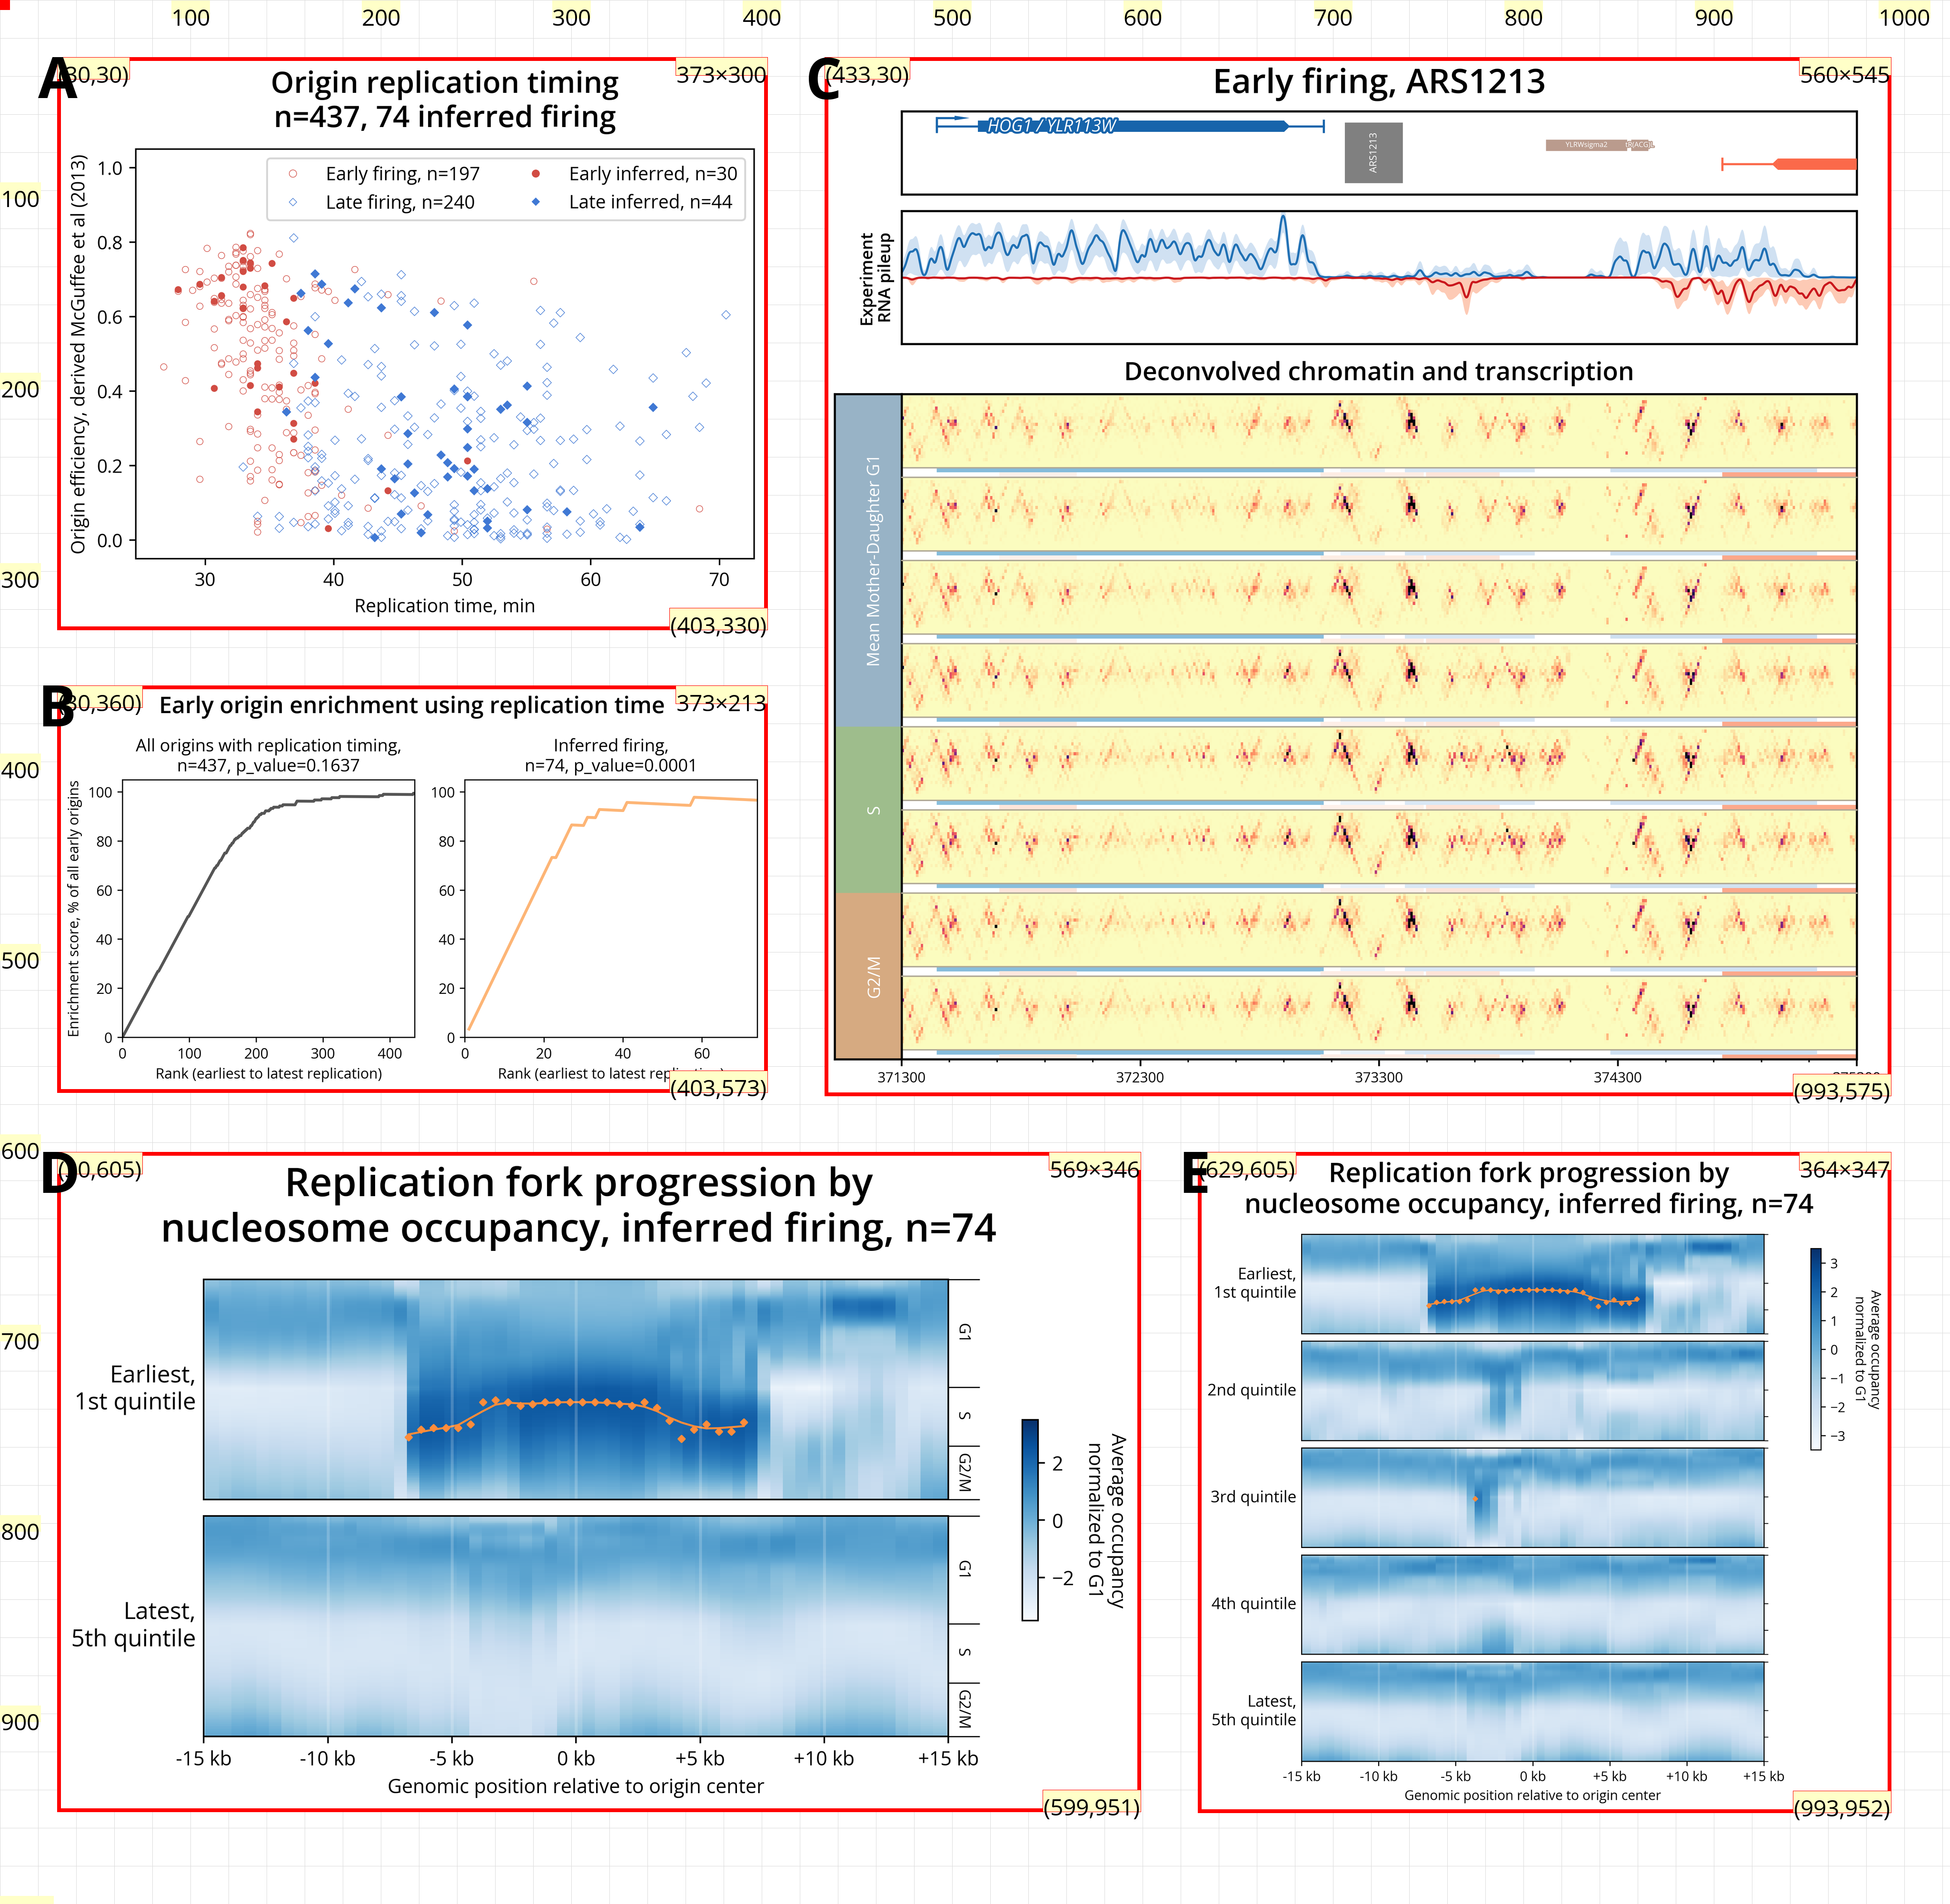

In [37]:
from IPython.display import Image, display
fig_origins.layout_panel()
display(Image('output/draft4_run/Figures/Debug/Figure6_Origins_debug.png'))

Debug figure saved to: output/draft4_run//Figures/Debug/SupplementalX_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/SupplementalX_Origins.png


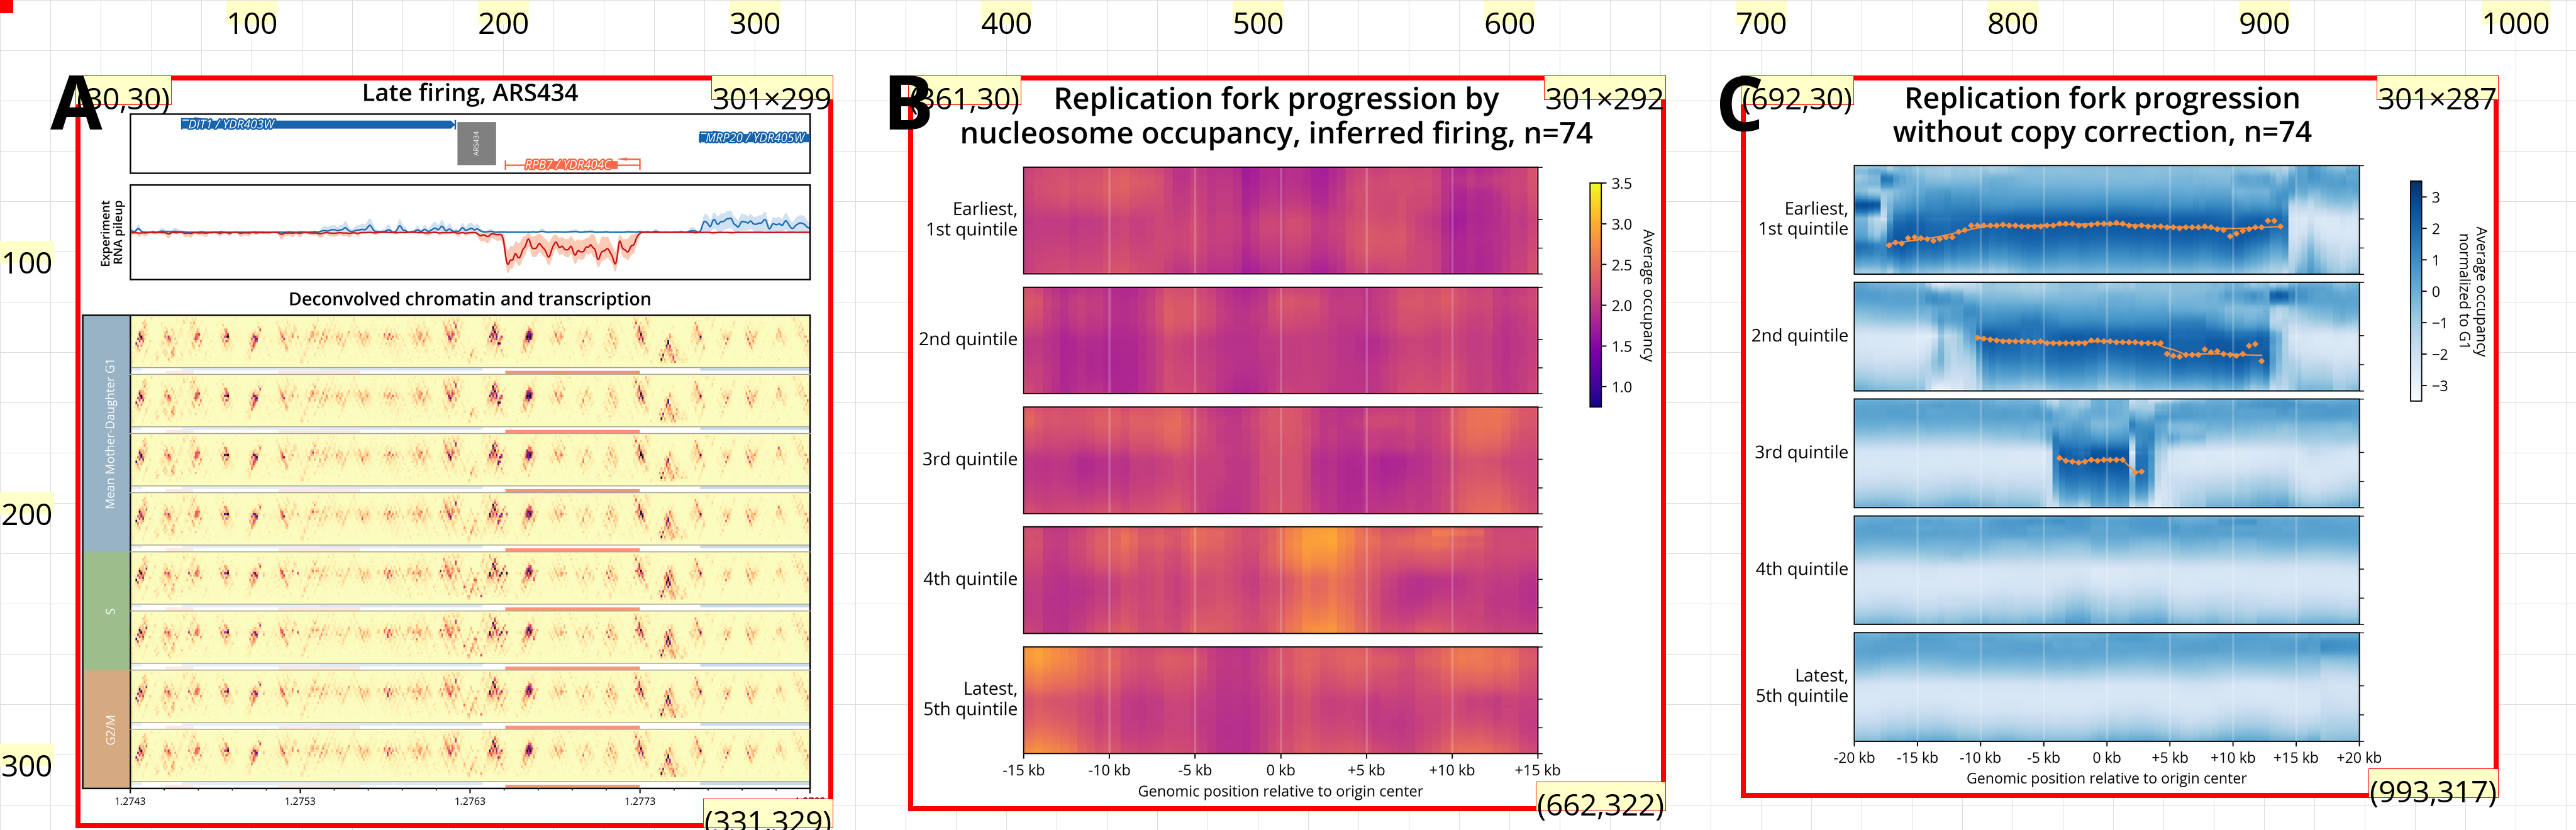

In [38]:
fig_origins.layout_supplemental_panel()
display(Image('output/draft4_run/Figures/Debug/SupplementalX_Origins_debug.png'))

In [844]:
from src.origin_entropy_processor import select_region_away, fold_halves_together, _compute_entropy_3d
from src.origin_entropy_processor import generate_origin_entropy_matrix

origins = origins.sort_values('replication_time')
inferred_firing_origins = origins[origins.inferred_firing]

deconv_inferred_origin_dist_entropies = generate_origin_entropy_matrix(
    inferred_firing_origins, deconvolved_loader, furthest_dist=furthest_dist, step=step)


Origin:  0
00:00:00.605
Origin:  1
00:00:01.218
Origin:  2
00:00:01.827
Origin:  3
00:00:02.441
Origin:  4
00:00:03.066
Origin:  5
00:00:03.668
Origin:  6
00:00:04.276
Origin:  7
00:00:04.888
Origin:  8
00:00:05.504
Origin:  9
00:00:06.099
Origin:  10
00:00:06.705
Origin:  11
00:00:07.351
Origin:  12
00:00:07.965
Origin:  13
00:00:08.564
Origin:  14
00:00:09.171
Origin:  15
00:00:09.810
Origin:  16
00:00:10.376
Origin:  17
00:00:10.945
Origin:  18
00:00:11.546
Origin:  19
00:00:12.157
Origin:  20
00:00:12.759
Origin:  21
00:00:13.371
Origin:  22
00:00:13.981
Origin:  23
00:00:14.543
Origin:  24
00:00:15.150
Origin:  25
00:00:15.760
Origin:  26
00:00:16.386
Origin:  27
00:00:16.999
Origin:  28
00:00:17.599
Origin:  29
00:00:18.206
Origin:  30
00:00:18.807
Origin:  31
00:00:21.382
Origin:  32
00:00:21.974
Origin:  33
00:00:22.583
Origin:  34
00:00:23.183
Origin:  35
00:00:23.790
Origin:  36
00:00:24.386
Origin:  37
00:00:24.986
Origin:  38
00:00:25.610
Origin:  39
00:00:26.237
Origin:  4

[32, 80, 112] [0, 64, 97, 127]


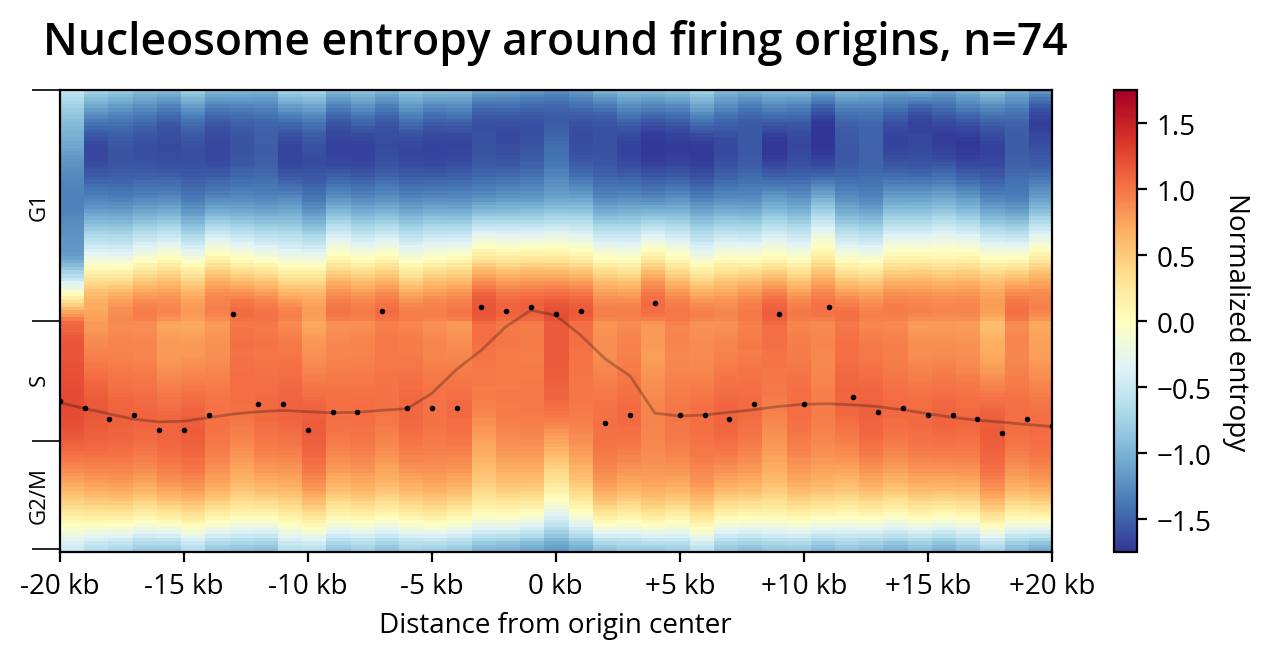

In [918]:
from src.origin_entropy_processor import plot_entropy_by_distance

plot_entropy_by_distance(deconv_inferred_origin_dist_entropies, config1,
                        furthest_dist=furthest_dist, step=step)